In [41]:
import numpy as np
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')


In [42]:
# Data Download
df = yf.download('SPY', start='2016-01-01', end='2026-12-31',auto_adjust=False, interval='1d',multi_level_index=False)

# Cleaning Data
df.drop(columns=['Close','High','Low','Open','Volume'], inplace=True)
df.dropna(inplace=True)


# Model Training
window = 100
pred = []
dates = []
ma_coef = []

for i in range(window,len(df)):

    train = df['Adj Close'][i-window:i]

    model = ARIMA(train, order=(0,1,1)).fit()
    forecast = model.forecast(steps = 1)

    pred.append(forecast.iloc[0])
    dates.append(df.index[i])
    coef = model.params.get('ma.L1',None)
    ma_coef.append(coef)


pred_series = pd.Series(pred,index = dates)
df['prediction'] = pred_series
coef_series = pd.Series(ma_coef,index = dates)
df['ma_coef'] = coef_series
df.dropna(inplace=True)

df['Residual'] = df['Adj Close'] - df['prediction']

# Residual Mean over time
plt.plot(df['Residual'])
plt.show()

# Residual Distribution Pattern
sns.histplot(df['Residual'],kde=True)
plt.show()

# Rolling mean
plt.plot(df['Residual'].rolling(50).mean())
plt.show()

# for Finding Fat tails in Data
import statsmodels.api as sm
sm.qqplot(df['Residual'],line='s', fit=True)
plt.show()



[*********************100%***********************]  1 of 1 completed


In [58]:
df['returns'] = df['Adj Close'].pct_change()
df['signal'] = np.where(df['prediction'] > df['Adj Close'].shift(1), 1, -1)
df['strategy_returns'] = df['signal'] * df['returns']
df.dropna(inplace=True)

Total Strategy Return: 12.56%
Annualized Return: 1.21%
Sharpe Ratio: 0.16
Max Drawdown: -36.96%


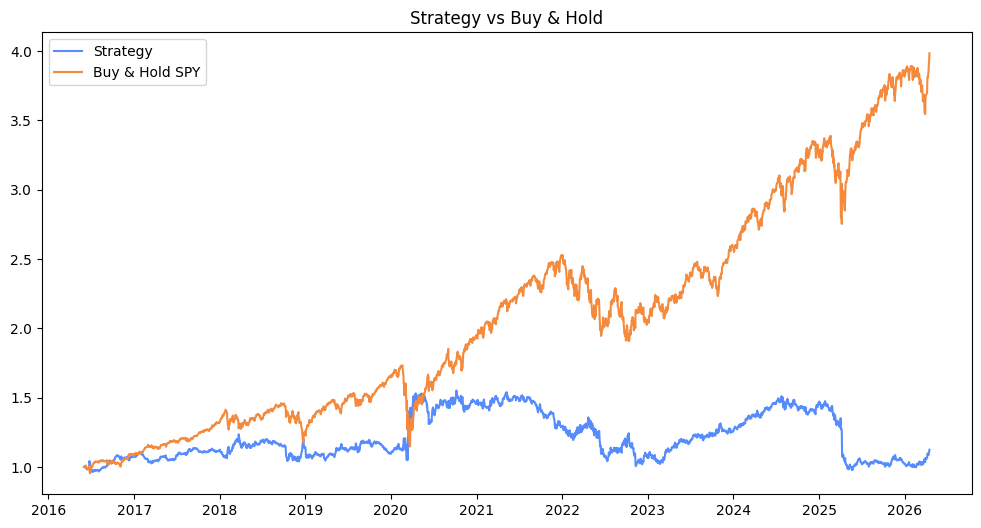

In [59]:
# Cumulative performance
df['cum_strategy'] = (1 + df['strategy_returns']).cumprod()
df['cum_market'] = (1 + df['returns']).cumprod()

# Basic metrics
total_return = df['cum_strategy'].iloc[-1] - 1
ann_return = (1 + total_return) ** (252 / len(df)) - 1
sharpe = df['strategy_returns'].mean() / df['strategy_returns'].std() * np.sqrt(252) if df['strategy_returns'].std() != 0 else 0
max_dd = (df['cum_strategy'] / df['cum_strategy'].cummax() - 1).min()

print(f"Total Strategy Return: {total_return:.2%}")
print(f"Annualized Return: {ann_return:.2%}")
print(f"Sharpe Ratio: {sharpe:.2f}")
print(f"Max Drawdown: {max_dd:.2%}")

# Plots
plt.figure(figsize=(12,6))
plt.plot(df['cum_strategy'], label='Strategy')
plt.plot(df['cum_market'], label='Buy & Hold SPY')
plt.legend()
plt.title('Strategy vs Buy & Hold')
plt.show()

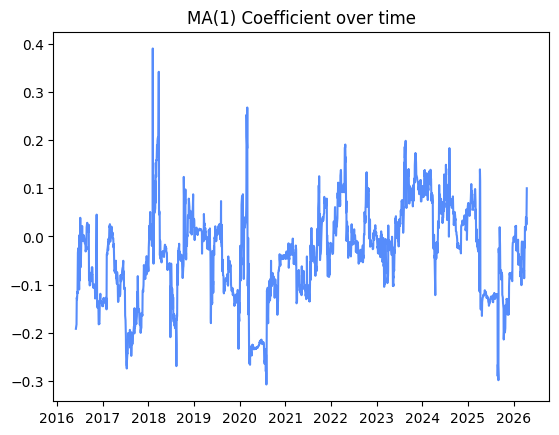

In [60]:
plt.plot(df['ma_coef'])
plt.title('MA(1) Coefficient over time')
plt.show()